In [2]:
import tensorflow as tf
import os
from tensorflow import keras
from keras import Sequential
from tensorflow.keras.layers import Dense,Flatten,GlobalAveragePooling2D,Dropout
from keras.applications.xception import Xception
import cv2
import imghdr
import numpy as np
import matplotlib.pyplot as plt

I0000 00:00:1786860072.926152    1616 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786860073.677396    1616 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786860077.697166    1616 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
gpus=tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
  tf.config.experimental.set_memory_growth(gpu,True)

In [4]:
conv_base=Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(299,299,3)
)
conv_base.summary()

I0000 00:00:1786860103.526019    1616 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 149, 149,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 149, 149,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 147, 147,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 147, 147,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 147, 147,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 147, 147,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 147, 147,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 147, 147,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 147, 147,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 147, 147,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 74, 74,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 74, 74,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 74, 74,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 74, 74,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 74, 74,    │          0 │ add[0][0]       

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 20,806,952 (79.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [5]:
conv_base.trainable = True

for layer in conv_base.layers[:-20]:
    layer.trainable = False

In [6]:
from tensorflow.keras.layers import BatchNormalization
model = Sequential()

model.add(conv_base)
model.add(GlobalAveragePooling2D())

model.add(BatchNormalization())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

In [7]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_xception.keras",
    monitor="val_accuracy",
    save_best_only=True
)

checkpoint = ModelCheckpoint(
    "./training_backup2.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [11]:
DATASET_DIR = "/mnt/d/dl/deepfake/dataset"
TRAIN_CSV = "/mnt/d/dl/deepfake/dataset/train.csv"
TEST_CSV = "/mnt/d/dl/deepfake/dataset/test.csv"

TRAIN_DIR = "/mnt/d/dl/deepfake/dataset/train_data"
TEST_DIR = "/mnt/d/dl/deepfake/dataset/test_data_v2"

In [12]:
import csv
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split

IMG_SIZE = (299, 299)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


# -----------------------------
# Read train.csv
# -----------------------------
image_paths = []
labels = []

with open(TRAIN_CSV, "r") as f:
    reader = csv.DictReader(f)

    for row in reader:
        image_path = os.path.join(DATASET_DIR, row["file_name"])
        label = int(row["label"])

        image_paths.append(image_path)
        labels.append(label)


# -----------------------------
# Train / Validation split
# -----------------------------
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)


# -----------------------------
# Image loading function
# -----------------------------
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label


# -----------------------------
# Create train dataset
# -----------------------------
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

train_ds = train_ds.shuffle(
    buffer_size=len(train_paths),
    seed=42
)

train_ds = train_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(AUTOTUNE)


# -----------------------------
# Create validation dataset
# -----------------------------
val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(AUTOTUNE)


# -----------------------------
# Read test.csv
# -----------------------------
test_paths = []

with open(TEST_CSV, "r") as f:
    reader = csv.DictReader(f)

    for row in reader:
        image_path = os.path.join(DATASET_DIR, row["id"])
        test_paths.append(image_path)


# -----------------------------
# Test image loading
# -----------------------------
def load_test_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    return image


test_ds = tf.data.Dataset.from_tensor_slices(test_paths)

test_ds = test_ds.map(
    load_test_image,
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [13]:
print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Test images:", len(test_paths))

Training images: 63960
Validation images: 15990
Test images: 5540


In [14]:
from tensorflow.keras.applications.xception import preprocess_input

train = train_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

val = val_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

test = test_ds.map(
    preprocess_input,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [15]:
import keras
keras.config.disable_traceback_filtering()

In [16]:
history2 = model.fit(
    
    train,
    validation_data=val,
    epochs=5,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/5


I0000 00:00:1786861554.060420    1835 service.cc:153] XLA service 0x784ba4067de0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786861554.060585    1835 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1786861554.766471    1835 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786861561.400850    1835 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1786861562.016152    1835 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12277__.155
E0000 00:00:1786861569.923394    1835 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786861570.305622    1835 cuda_timer.cc:87] Delay kernel time

1998/1999 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.6897 - loss: 0.6147

I0000 00:00:1786861968.647795    1836 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12277__.155
E0000 00:00:1786861971.255244    1836 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786861972.182803    1836 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786861974.236446    1836 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786861981.453560    1836 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786861981.996820    1836 cuda_timer.cc:87] Delay kernel timed ou

1999/1999 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.6898 - loss: 0.6146

E0000 00:00:1786862093.250113    1834 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786862094.711991    1834 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786862097.886141    1834 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786862100.564528    1834 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786862101.813920    1834 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1999/1999 ━━━━━━━━━━━━━━━━━━━━ 569s 247ms/step - accuracy: 0.7935 - loss: 0.4435 - val_accuracy: 0.9238 - val_loss: 0.1846 - learning_rate: 1.0000e-05
Epoch 2/5
1999/1999 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.9218 - loss: 0.2013

W0000 00:00:1786862775.590833    7333 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 67109120 bytes after encountering the first element of size 67109120 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1999/1999 ━━━━━━━━━━━━━━━━━━━━ 811s 405ms/step - accuracy: 0.9342 - loss: 0.1708 - val_accuracy: 0.9667 - val_loss: 0.0859 - learning_rate: 1.0000e-05
Epoch 3/5
1999/1999 ━━━━━━━━━━━━━━━━━━━━ 616s 307ms/step - accuracy: 0.9694 - loss: 0.0831 - val_accuracy: 0.9817 - val_loss: 0.0475 - learning_rate: 1.0000e-05
Epoch 4/5
1999/1999 ━━━━━━━━━━━━━━━━━━━━ 687s 343ms/step - accuracy: 0.9802 - loss: 0.0535 - val_accuracy: 0.9864 - val_loss: 0.0366 - learning_rate: 1.0000e-05
Epoch 5/5
1999/1999 ━━━━━━━━━━━━━━━━━━━━ 609s 304ms/step - accuracy: 0.9874 - loss: 0.0367 - val_accuracy: 0.9899 - val_loss: 0.0287 - learning_rate: 1.0000e-05


In [17]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_true = []
y_prob = []

for images, labels in val:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_prob.extend(predictions.ravel())

y_true = np.array(y_true)
y_prob = np.array(y_prob)

# Convert probability to class
y_pred = (y_prob >= 0.5).astype(int)

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))
print("ROC-AUC  :", roc_auc_score(y_true, y_prob))

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Class 0", "Class 1"]
    )
)

Accuracy : 0.9898686679174484
Precision: 0.9888902758706778
Recall   : 0.9908692933083177
F1 Score : 0.9898787954517057
ROC-AUC  : 0.9993961673200222

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.99      0.99      0.99      7995
     Class 1       0.99      0.99      0.99      7995

    accuracy                           0.99     15990
   macro avg       0.99      0.99      0.99     15990
weighted avg       0.99      0.99      0.99     15990



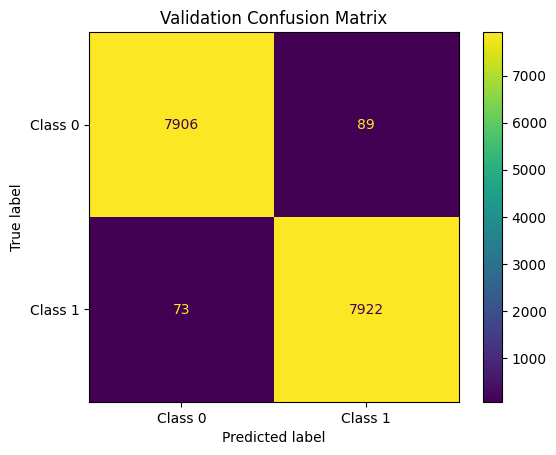

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
)

disp.plot()
plt.title("Validation Confusion Matrix")
plt.show()

In [19]:
val_loss, val_accuracy = model.evaluate(val, verbose=1)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

500/500 ━━━━━━━━━━━━━━━━━━━━ 62s 123ms/step - accuracy: 0.9899 - loss: 0.0287
Validation Loss: 0.02867472916841507
Validation Accuracy: 0.9898686408996582


[[7906   89]
 [  73 7922]]


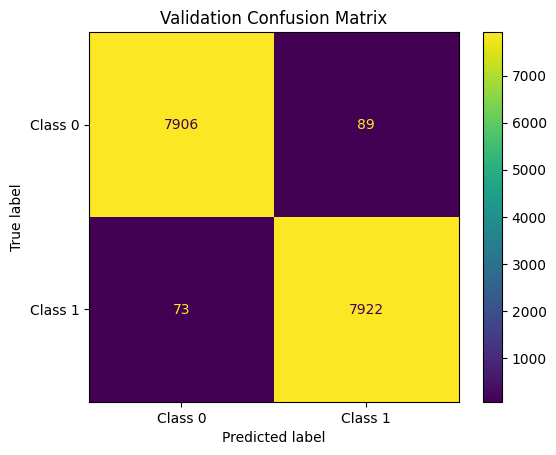

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
)

disp.plot()
plt.title("Validation Confusion Matrix")
plt.show()

In [22]:
import os

MODEL_DIR = "/mnt/d/dl/deepfake/backend/app/models"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = "/mnt/d/dl/deepfake/backend/app/models/truelens_model.keras"

model.save(MODEL_PATH)

print("Model saved successfully!")
print(MODEL_PATH)

Model saved successfully!
/mnt/d/dl/deepfake/backend/app/models/truelens_model.keras
